# Q10.
```{admonition}
:class: note
This exercise involves the `Boston` data set.

## (a)
```{admonition}
:class: note
Load in the `Boston` data set.

In [1]:
import pandas as pd
import numpy as np
boston = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Boston.csv',usecols = range(1,14))

## (b)
```{admonition}
:class: note
How many rows and columns are in this data set? What do they represent?

In [2]:
r,c = boston.shape
print(f'There are {r} rows and {c} columns.')

There are 506 rows and 13 columns.


Each row corresponds to a suburb of Boston with data given as:

- `crim`: per capita crime rate by town.
- `zn`: proportion of residential land zoned for lots over 25,000 sq.ft.
- `indus`: proportion of non-retail business acres per town.
- `chas`: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- `nox`: nitrogen oxides concentration (parts per 10 million).
- `rm`: average number of rooms per dwelling.
- `age`: proportion of owner-occupied units built prior to 1940.
- `dis`: weighted mean of distances to five Boston employment centres.
- `rad`: index of accessibility to radial highways.
- `tax`: full-value property-tax rate per \$10,000.
- `ptratio`: pupil-teacher ratio by town.
- `lstat`: lower status of the population (percent).
- `medv`: median value of owner-occupied homes in $1000s.

In [3]:
boston.sample(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
54,0.01360,75.0,4.00,0,0.410,5.888,47.6,7.3197,3,469,21.1,14.80,18.9
417,25.94060,0.0,18.10,0,0.679,5.304,89.1,1.6475,24,666,20.2,26.64,10.4
62,0.11027,25.0,5.13,0,0.453,6.456,67.8,7.2255,8,284,19.7,6.73,22.2


## (c)
```{admonition}
:class: note
Makesome pairwise scatterplots of the predictors in this data set.

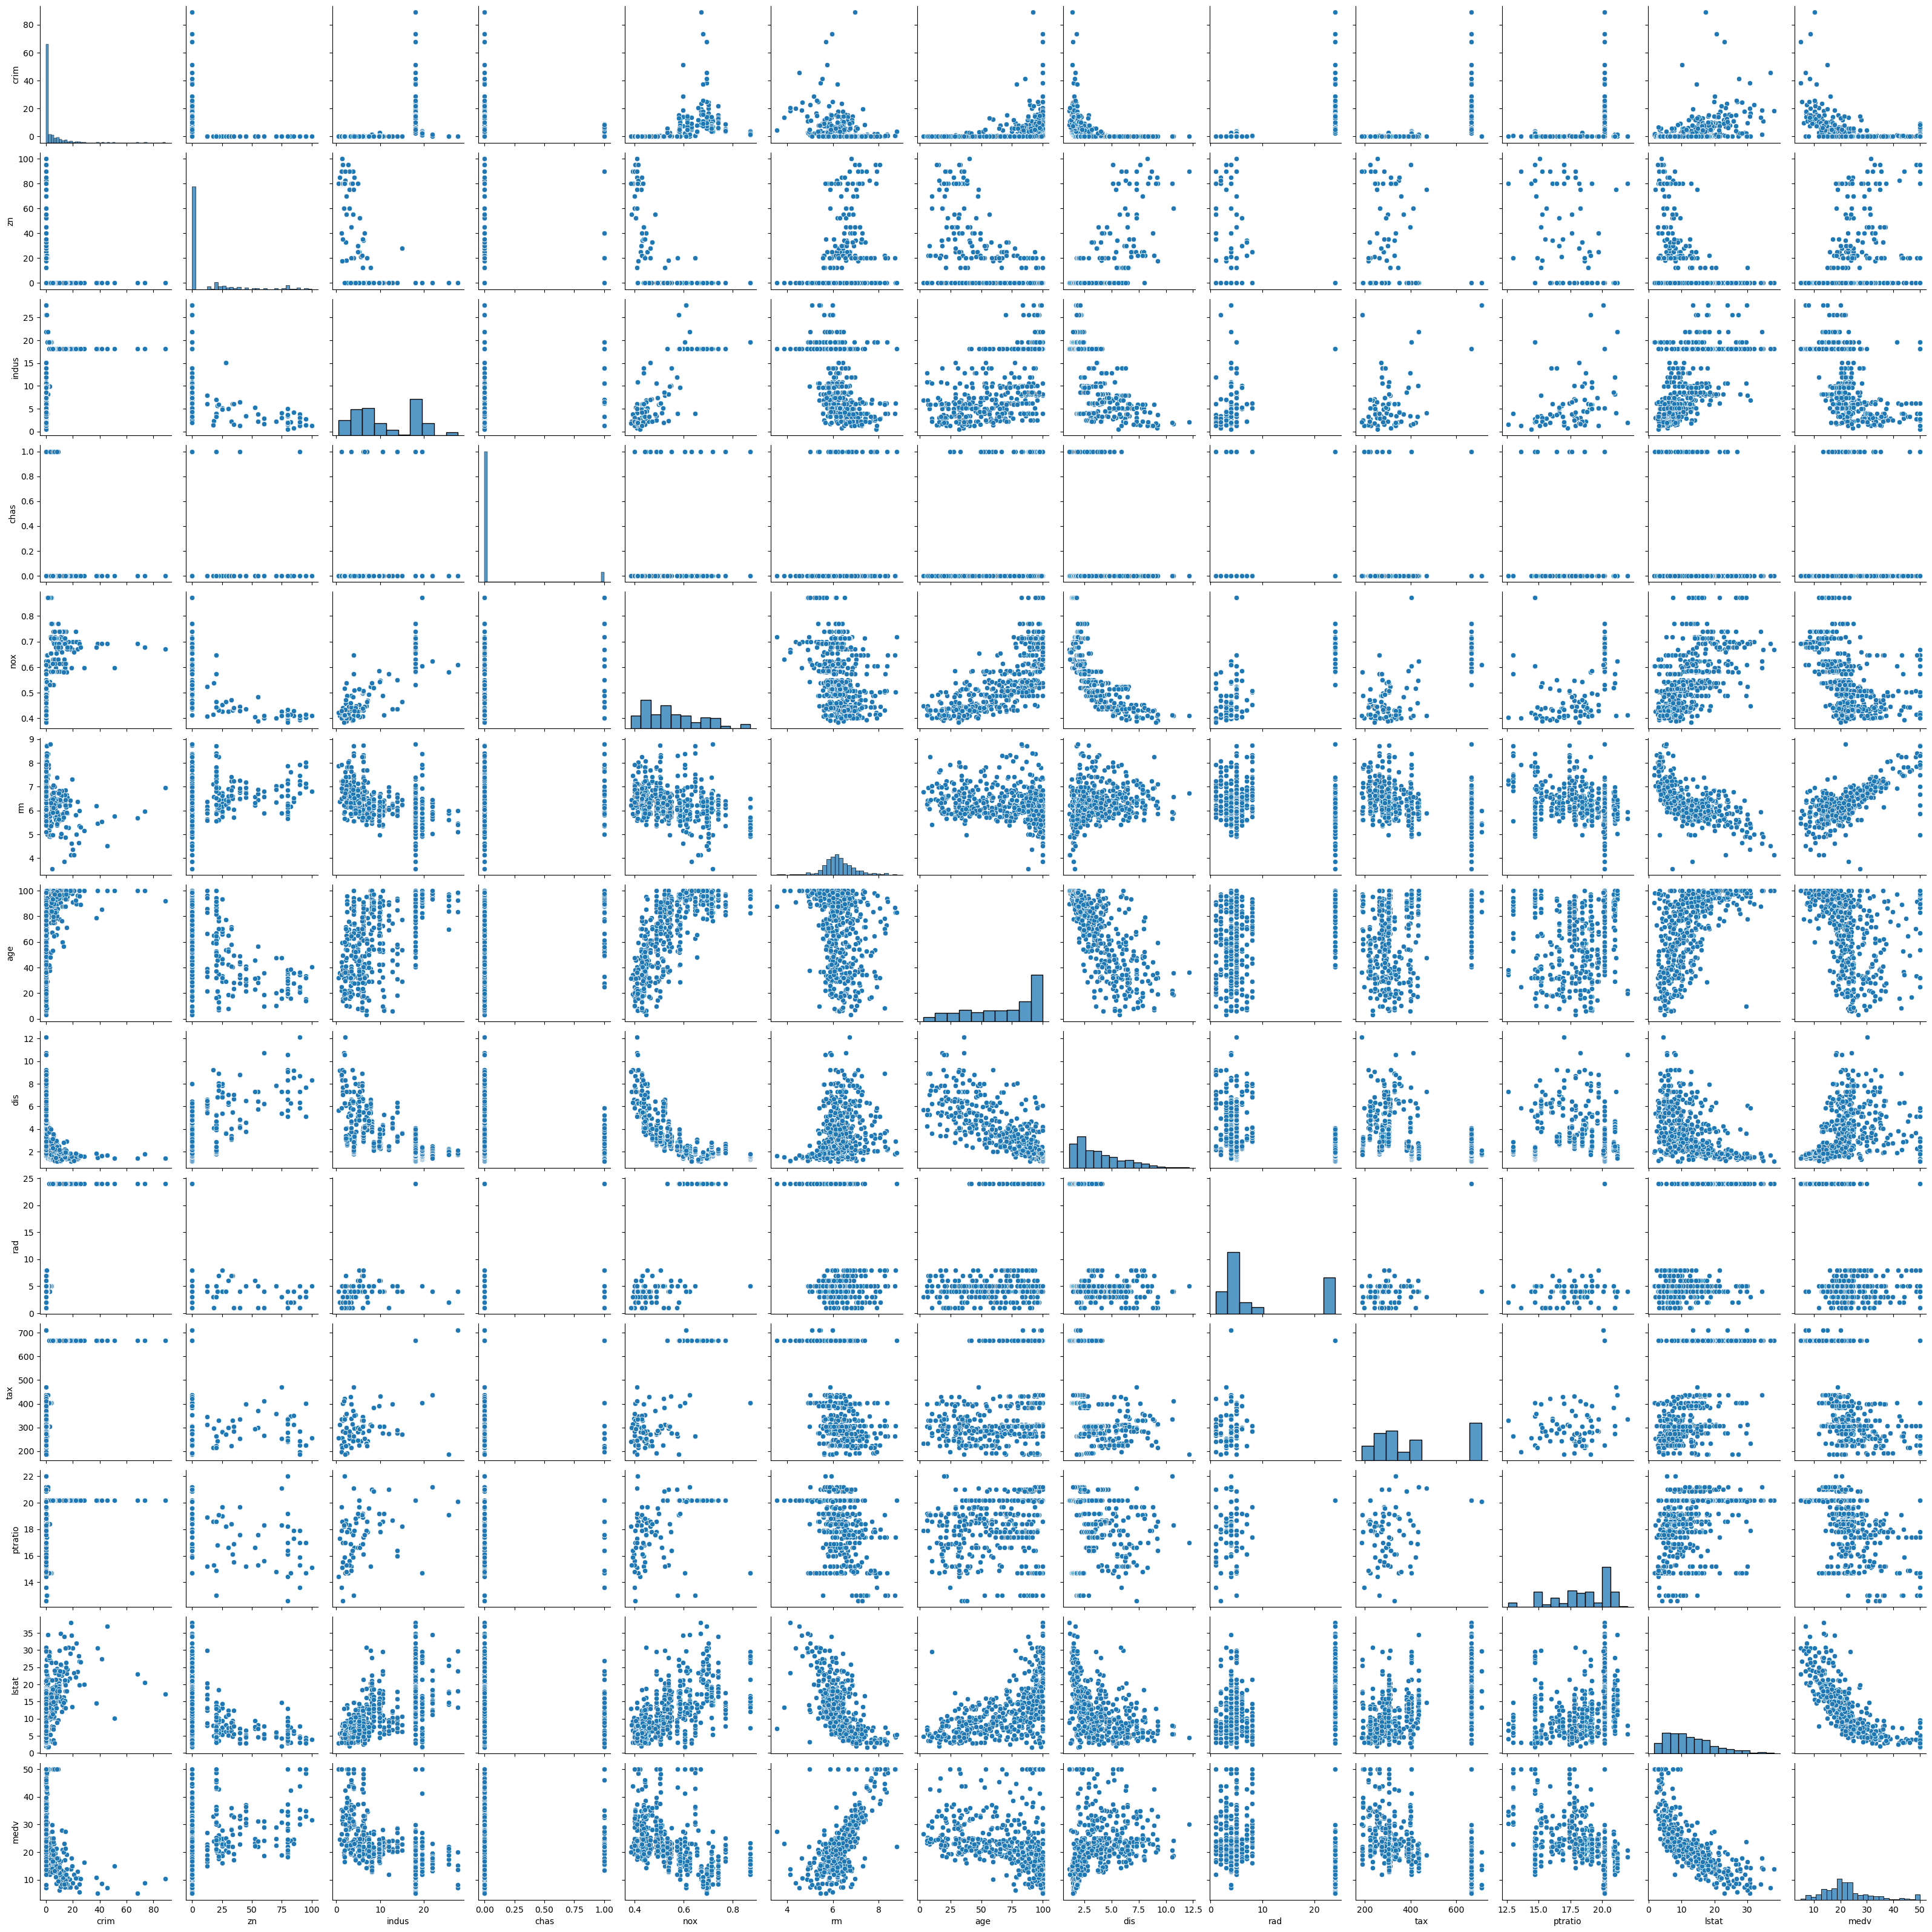

In [4]:
import seaborn as sns
sns.pairplot(boston) ;

## (d)
```{admonition}
:class: note
Are any of the predictors associated with per capita crime rate?

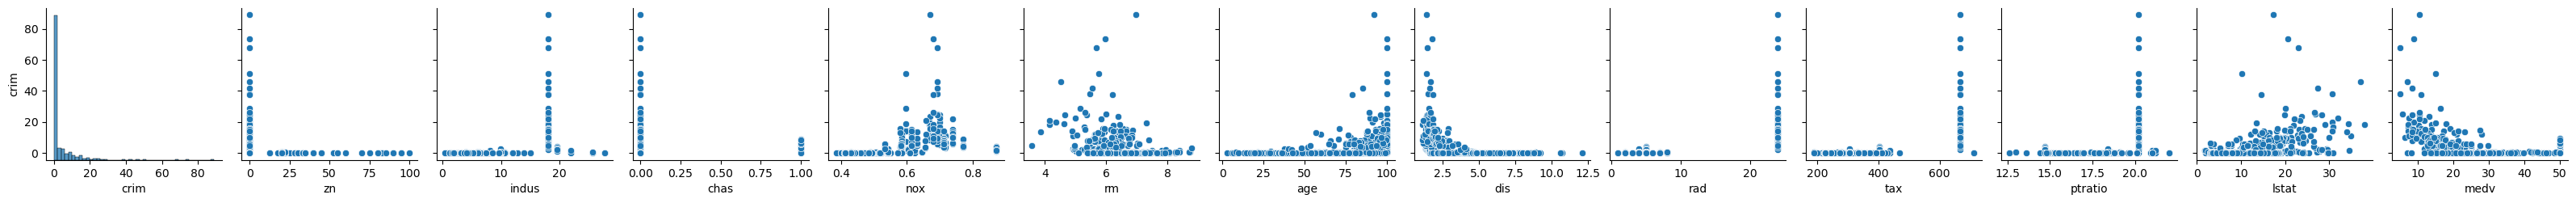

In [5]:
sns.pairplot(boston,y_vars = 'crim') ;

## (e)
```{admonition}
:class: note
Do any of the suburbs of Boston appear to have particularly high crime rates? Tax rates? Pupil-teacher ratios? Comment on the range of each predictor.

In [6]:
boston[['crim','tax','ptratio']].describe()

,crim,tax,ptratio
count,506.000000,506.000000,506.000000
mean,3.613524,408.237154,18.455534
std,8.601545,168.537116,2.164946
min,0.006320,187.000000,12.600000
25%,0.082045,279.000000,17.400000
50%,0.256510,330.000000,19.050000
75%,3.677083,666.000000,20.200000
max,88.976200,711.000000,22.000000


In [7]:
pd.DataFrame({'Range':Boston[['crim','tax','ptratio']].max()-Boston[['crim','tax','ptratio']].min()}).transpose()

NameError: name 'Boston' is not defined

In [ ]:
pd.cut(boston['crim'],bins=np.arange(0,101,20)).value_counts()

crim
(0, 20]      488
(20, 40]      12
(40, 60]       3
(60, 80]       2
(80, 100]      1
Name: count, dtype: int64

In [ ]:
boston[boston['crim'] > 60]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
380,88.9762,0.0,18.1,0,0.671,6.968,91.9,1.4165,24,666,20.2,17.21,10.4
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,22.98,5.0
418,73.5341,0.0,18.1,0,0.679,5.957,100.0,1.8026,24,666,20.2,20.62,8.8


In [ ]:
pd.cut(boston['tax'],bins=np.arange(100,801,100)).value_counts()

tax
(200, 300]    155
(300, 400]    134
(600, 700]    132
(400, 500]     63
(100, 200]     17
(700, 800]      5
(500, 600]      0
Name: count, dtype: int64

In [ ]:
boston[boston['tax'] > 700]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
488,0.15086,0.0,27.74,0,0.609,5.454,92.7,1.8209,4,711,20.1,18.06,15.2
489,0.18337,0.0,27.74,0,0.609,5.414,98.3,1.7554,4,711,20.1,23.97,7.0
490,0.20746,0.0,27.74,0,0.609,5.093,98.0,1.8226,4,711,20.1,29.68,8.1
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,18.07,13.6
492,0.11132,0.0,27.74,0,0.609,5.983,83.5,2.1099,4,711,20.1,13.35,20.1


In [ ]:
pd.cut(boston['ptratio'],bins=np.arange(12,23,2)).value_counts()

ptratio
(20, 22]    201
(18, 20]    115
(16, 18]    105
(14, 16]     69
(12, 14]     16
Name: count, dtype: int64

## (f)
```{admonition}
:class: note
How many of the suburbs in this data set bound the Charles river?

In [ ]:
bound_charles = boston['chas'].sum()
print(f'There are {bound_charles} suburbs bounding the Charles river.')

There are 35 suburbs bounding the Charles river.


## (g)
```{admonition}
:class: note
what is the median pupil-teacher ratio among the towns in this data set?

In [ ]:
ptratio_median = boston['ptratio'].median()
print(f'The median pupil-teacher ratio is {ptratio_median}')

The median pupil-teacher ratio is 19.05


## (h)
```{admonition}
:class: note
Which suburb of Boston has lowest median value of owner-occupied homes? What are the values of the other predictors for that suburb, and how do those values compare to the overall ranges for those predictors? 

In [ ]:
boston.iloc[boston['medv'].idxmin()]

crim        38.3518
zn           0.0000
indus       18.1000
chas         0.0000
nox          0.6930
rm           5.4530
age        100.0000
dis          1.4896
rad         24.0000
tax        666.0000
ptratio     20.2000
lstat       30.5900
medv         5.0000
Name: 398, dtype: float64

In [ ]:
pd.DataFrame({'Range':boston.max()-boston.min(),'Minimum median value':boston.iloc[boston['medv'].idxmin()]}).transpose()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
Range,88.96988,100.0,27.28,1.0,0.486,5.219,97.1,10.9969,23.0,524.0,9.4,36.24,45.0
Minimum median value,38.35180,0.0,18.10,0.0,0.693,5.453,100.0,1.4896,24.0,666.0,20.2,30.59,5.0


## (i)
```{admonition}
:class: note
In this data set, how many of the suburbs average more than seven rooms per dwelling? More than eight rooms per dwelling?

In [ ]:
seven_room_plus = boston[boston['rm'] >= 7].shape[0]
eight_room_plus = boston[boston['rm'] >= 8].shape[0]

print(f'There are {seven_room_plus} suburbs that average more than seven rooms and {eight_room_plus} suburbs that average more than eight rooms.')

There are 64 suburbs that average more than seven rooms and 13 suburbs that average more than eight rooms.


In [ ]:
boston[boston['rm'] >= 8]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
97,0.12083,0.0,2.89,0,0.4450,8.069,76.0,3.4952,2,276,18.0,4.21,38.7
163,1.51902,0.0,19.58,1,0.6050,8.375,93.9,2.1620,5,403,14.7,3.32,50.0
204,0.02009,95.0,2.68,0,0.4161,8.034,31.9,5.1180,4,224,14.7,2.88,50.0
224,0.31533,0.0,6.20,0,0.5040,8.266,78.3,2.8944,8,307,17.4,4.14,44.8
225,0.52693,0.0,6.20,0,0.5040,8.725,83.0,2.8944,8,307,17.4,4.63,50.0
226,0.38214,0.0,6.20,0,0.5040,8.040,86.5,3.2157,8,307,17.4,3.13,37.6
232,0.57529,0.0,6.20,0,0.5070,8.337,73.3,3.8384,8,307,17.4,2.47,41.7
233,0.33147,0.0,6.20,0,0.5070,8.247,70.4,3.6519,8,307,17.4,3.95,48.3
253,0.36894,22.0,5.86,0,0.4310,8.259,8.4,8.9067,7,330,19.1,3.54,42.8
257,0.61154,20.0,3.97,0,0.6470,8.704,86.9,1.8010,5,264,13.0,5.12,50.0


In [ ]:
boston[boston['rm'] >= 8].describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.718795,13.615385,7.078462,0.153846,0.539238,8.348538,71.538462,3.430192,7.461538,325.076923,16.361538,4.310000,44.200000
std,0.901640,26.298094,5.392767,0.375534,0.092352,0.251261,24.608723,1.883955,5.332532,110.971063,2.410580,1.373566,8.092383
min,0.020090,0.000000,2.680000,0.000000,0.416100,8.034000,8.400000,1.801000,2.000000,224.000000,13.000000,2.470000,21.900000
25%,0.331470,0.000000,3.970000,0.000000,0.504000,8.247000,70.400000,2.288500,5.000000,264.000000,14.700000,3.320000,41.700000
50%,0.520140,0.000000,6.200000,0.000000,0.507000,8.297000,78.300000,2.894400,7.000000,307.000000,17.400000,4.140000,48.300000
75%,0.578340,20.000000,6.200000,0.000000,0.605000,8.398000,86.500000,3.651900,8.000000,307.000000,17.400000,5.120000,50.000000
max,3.474280,95.000000,19.580000,1.000000,0.718000,8.780000,93.900000,8.906700,24.000000,666.000000,20.200000,7.440000,50.000000
